# Where Your Degree Takes You — 3. Geography, Affordability & the Debt Paradox

Where a degree's jobs are, whether the pay covers the rent, and the headline finding: **debt and earnings are barely correlated across majors.**

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor": "#0a0a0a", "axes.facecolor": "#0a0a0a",
                     "savefig.facecolor": "#0a0a0a", "axes.edgecolor": "#444",
                     "font.size": 11, "axes.grid": True, "grid.alpha": 0.15})
PURPLE, GREEN, ROSE = "#a855f7", "#10b981", "#f43f5e"
DATA = os.environ.get("DEGREE_DATA", os.path.join("..", "public", "data", "degree"))
load = lambda n: json.load(open(os.path.join(DATA, n), encoding="utf-8"))
print("Reading committed data from:", os.path.abspath(DATA))

Reading committed data from: C:\Users\jelbe\palavir-estate-audit\repos\data-portfolio\public\data\degree


## The debt paradox

Across Bachelor's majors, does more debt buy more pay? We recompute the Pearson correlations from the major landscape.

In [2]:
L = pd.DataFrame(load('major_landscape.json')['majors'])
def r(a,b):
    m = L[[a,b]].dropna(); return np.corrcoef(m[a], m[b])[0,1]
print(f"debt  vs earnings : r = {r('debt','earn_5yr'):+.3f}")
print(f"AI    vs earnings : r = {r('ai_beta','earn_5yr'):+.3f}")
print(f"growth vs earnings: r = {r('growth_pct','earn_5yr'):+.3f}")
print('stored:', load('national_overview.json')['correlations'])

debt  vs earnings : r = +0.056
AI    vs earnings : r = +0.181
growth vs earnings: r = -0.128
stored: {'debt_vs_earnings': 0.056, 'ai_exposure_vs_earnings': 0.181, 'growth_vs_earnings': -0.128, 'notes': "Across Bachelor's-level majors. Pearson r. Observational."}


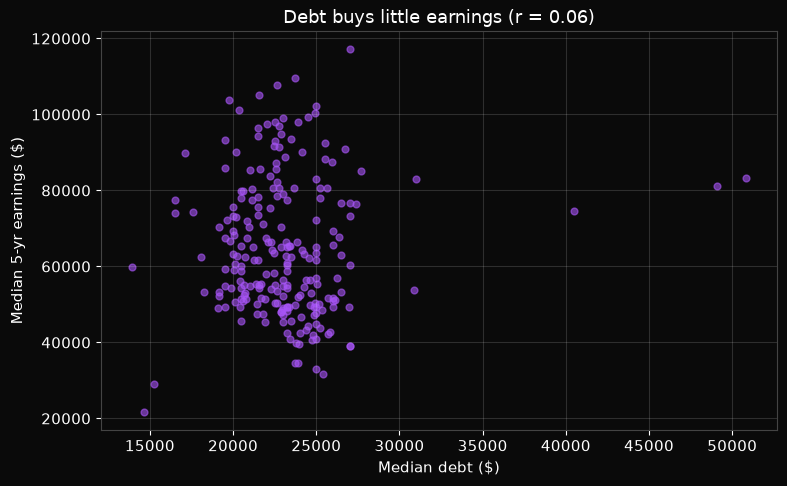

In [3]:
fig, ax = plt.subplots(figsize=(8,5))
m = L.dropna(subset=['debt','earn_5yr'])
ax.scatter(m['debt'], m['earn_5yr'], s=24, c=PURPLE, alpha=0.6)
ax.set_xlabel('Median debt ($)'); ax.set_ylabel('Median 5-yr earnings ($)')
ax.set_title(f"Debt buys little earnings (r = {r('debt','earn_5yr'):.2f})")
plt.tight_layout(); plt.show()

An almost flat cloud (r ≈ 0.05): taking on more debt does **not** systematically buy more earning power. The lever that matters is *field*, not *spend*.

## Where the jobs cluster

From BLS OEWS we compute each state's **location quotient** — how over-represented a degree's occupations are vs. the national average (after dropping generic catch-all occupations like 'Managers' that the crosswalk attaches to every field). Petroleum Engineering is the classic test:

In [4]:
pet = load('by_cip_geo/1425.json')  # Petroleum Engineering
top = sorted([(k,v) for k,v in pet.items() if v.get('concentration')],
             key=lambda kv:-kv[1]['concentration'])[:8]
pd.DataFrame([{'state': v['name'], 'concentration_x': v['concentration'],
               'jobs_share_%': v.get('jobs_share'), 'wage': v.get('wage')} for _,v in top])

,state,concentration_x,jobs_share_%,wage
0,Alaska,10.00,1.59,205380
1,Oklahoma,8.30,7.45,155659
2,Texas,7.01,65.34,157011
3,Colorado,3.83,7.38,168740
4,Louisiana,3.47,4.34,145098
5,Utah,1.24,1.45,169820
6,California,0.54,7.02,136361
7,Pennsylvania,0.41,1.88,103618


Oklahoma, Texas, Alaska, Colorado, Louisiana — oil country, exactly right.

## Can the paycheck cover the rent?

We pit each major's graduate-weighted metro pay (OEWS) against market rent (Zillow), as a share of income. The classic guidance: **keep rent under 30%**. For Computer Science, how many metros clear that line?

In [5]:
metros = {m['cbsa']: m for m in load('affordability_metros.json')['metros']}
wage = load('by_cip_afford/1107.json')  # Computer Science
rows = []
for cbsa, w in wage.items():
    m = metros.get(int(cbsa))
    if m: rows.append({'metro': m['name'], 'wage': w, 'rent': m['zori_monthly'],
                       'burden_%': round(m['zori_monthly']*12/w*100,1)})
aff = pd.DataFrame(rows).sort_values('burden_%')
print(f"{(aff['burden_%']<=30).sum()} of {len(aff)} metros keep CS rent under 30%")
aff.head(6)

368 of 370 metros keep CS rent under 30%


,metro,wage,rent,burden_%
222,"Weirton, WV",110790,842,9.1
209,"Decatur, IL",110658,928,10.1
221,"Johnstown, PA",98542,873,10.6
273,"Wheeling, WV",105787,938,10.6
178,"Ames, IA",114533,1024,10.7
340,"Muncie, IN",103308,961,11.2


*Rent data: Data Provided by Zillow Group. OEWS covers fewer metros than Zillow, so unmatched metros are omitted — never estimated.*

---

### Sources & reproducibility
Every figure above is recomputed from the committed `public/data/degree/*.json`, which the pipeline in `scripts/degree/` derives from College Scorecard, BLS OEWS, NCES CIP→SOC, O\*NET, the Eloundou & AIOE AI-exposure datasets, and Zillow ZORI. See `sources.json` for full citations and licenses.